# Foldy-Lax Model

We demonstrate how to generate Green's matrices for the Foldy-Lax model.

In [14]:
using Pkg
Pkg.activate(".")

using LinearAlgebra, StaticArrays, SparseArrays
using Base.Threads
using CUDA, Adapt, KernelAbstractions, GPUArrays
using Plots, JLD2
using DictionaryLearning
using Base.Iterators

include("../debug.jl")

savepath = "../../temp/fl-example"

# plot theme
theme(:rose_pine)

# choose backend
back = CUDA.functional() ? CUDABackend() : CPU()

# threads
BLAS.set_num_threads(nthreads())

println("$INF backend: $back")
println("$INF # threads: $(nthreads())")

  Activating project at `~/DictionaryLearning/examples/foldy-lax`


[INF] backend: CUDABackend(false, false)
[INF] # threads: 32


Describe the recievers, scatterers, and sources/imaging window. We have a few presets:
1. A large, pretty example (a) without scatterers and (b) with scatterers
 to demonstrate the super-resolution effect.
2. A smaller version of 1b for the dictionary learning examples.

In [15]:
include("./presets.jl")

# (saveres, (frq, iwx, iwy, src, sct, rec, τ)) = false, preset1a() # no scatterers
# (saveres, (frq, iwx, iwy, src, sct, rec, τ)) = false, preset1b() # with scatterers
# (saveres, (frq, iwx, iwy, src, sct, rec, τ)) = true, preset2() # smaller 1b
(saveres, (frq, iwx, iwy, src, sct, rec, τ)) = true, preset3() # smaller 2
# (saveres, (frq, iwx, iwy, src, sct, rec, τ)) = true, preset4()

m = size(sct, 2)
k = size(src, 2)
n = size(rec, 2)
p = length(frq)

println("$INF # sources: $(k)")
println("$INF # scatterers: $(m)")
println("$INF # recievers: $(n)")
println("$INF # frequencies: $(p)")
println("$INF size(D): ($(n*p), $k)")

[INF] # sources: 169
[INF] # scatterers: 900
[INF] # recievers: 17
[INF] # frequencies: 15
[INF] size(D): (255, 169)


Move to backend and solve for Green's matrix.

In [ ]:
src = adapt(back, src)
sct = adapt(back, sct)
rec = adapt(back, rec)
frq = adapt(back, collect(frq))
τ = adapt(back, τ)

fls = let
    # preallocate stuff
    fls = FoldyLaxStruct(src, sct, rec, frq, τ)
    flws = FoldyLaxWorkStruct(fls)

    # do actual work
    foldylax!(fls, flws)

    fls
end

# force GPU cleanup
if back == CUDABackend()
    GC.gc()
    CUDA.reclaim()
end

;

Visualize the covariance of the impulse-responses of all pixels with the center pixel. All the dictionary-learning algorithms require the covariance of the impulse-response of distinct pixels to be small. This is important to keep in mind if the dictionary learning algorithms fail.

[INF] maximum coherence: 0.9324239602861218


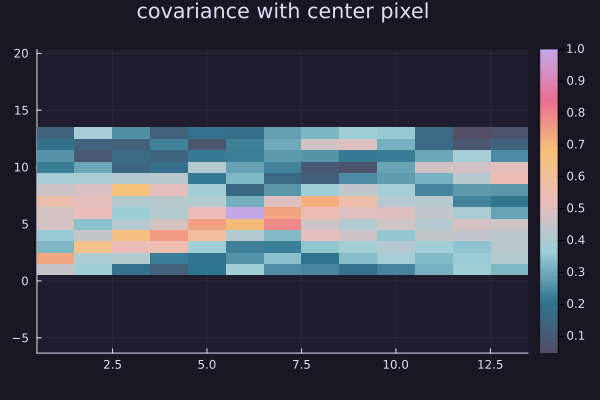

In [17]:
println("$INF maximum coherence: $(max_offdiag_coh(fls.G))")

let
    G = fls.G

    # create impulse
    ky, kx = length(iwy), length(iwx)
    ar = abs(maximum(iwy) - minimum(iwy))/abs(maximum(iwx) - minimum(iwx))
    x = zeros(ComplexF64, ky, kx)
    x[fld(ky,2), fld(kx,2)] = 1.0 + 0.0im
    x = adapt(back, x)

    # measure impulse response
    y = G * reshape(x, :) 

    # create KM image
    x2 = similar(x)
    reshape(x2, :) .= G' * y
    kmimg = adapt(CPU(), abs2.(x2))
    kmimg ./= maximum(kmimg)
    p1 = heatmap(kmimg, ratio=ar, title="covariance with center pixel")
    savefig("$savepath/cov.pdf")
    p1
end

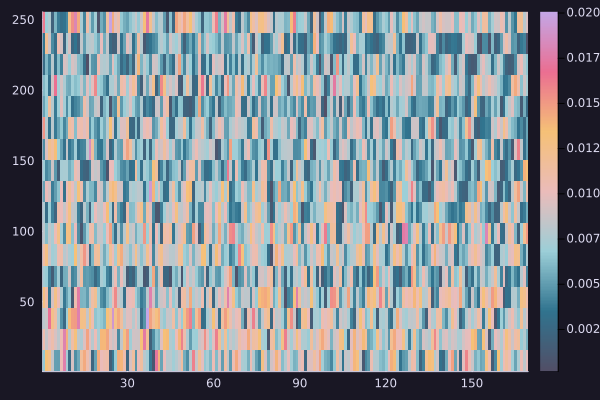

In [18]:
let
    G = fls.G

    heatmap(adapt(CPU(), abs.(G)))
end

Save to be used by other examples.

In [19]:
# save fls
if saveres
    @save "$savepath/fls.jld2" fls
end